In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#task 1 Load and Explore the Titanic Dataset

First 5 rows:
    survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----  

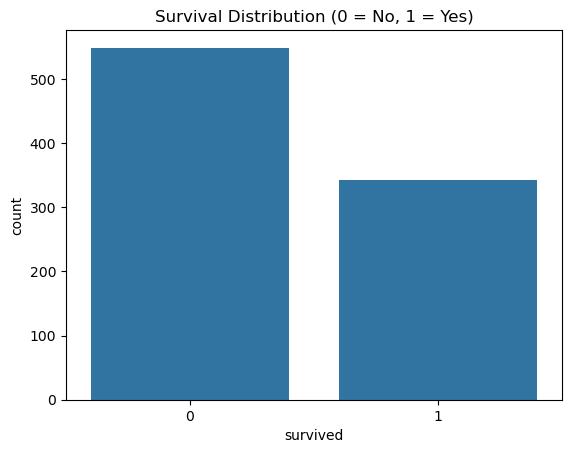

In [9]:
# Load Titanic dataset from seaborn
data = sns.load_dataset("titanic")

# Display first few rows
print("First 5 rows:\n", data.head())

# Dataset info
print("\nDataset Info:")
print(data.info())

# Summary statistics
print("\nSummary Statistics:")
print(data.describe(include='all'))

# Target variable distribution
sns.countplot(x="survived", data=data)
plt.title("Survival Distribution (0 = No, 1 = Yes)")
plt.show()


In [4]:
#task 2 Data Cleaning and Preprocessing

In [10]:
# Fill missing values
data['age'] = data['age'].fillna(data['age'].median())
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])

# Drop irrelevant columns
data.drop(columns=['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male'], inplace=True)

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

# Binary encoding (sex)
le = LabelEncoder()
data['sex'] = le.fit_transform(data['sex'])  # male=1, female=0

# One-hot encoding for 'embarked'
data = pd.get_dummies(data, columns=['embarked'], drop_first=True)

print("Processed Data:\n", data.head())


Processed Data:
    survived  pclass  sex   age  sibsp  parch     fare  alone  embarked_Q  \
0         0       3    1  22.0      1      0   7.2500  False       False   
1         1       1    0  38.0      1      0  71.2833  False       False   
2         1       3    0  26.0      0      0   7.9250   True       False   
3         1       1    0  35.0      1      0  53.1000  False       False   
4         0       3    1  35.0      0      0   8.0500   True       False   

   embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  


In [6]:
#task 3 

In [7]:
# Select relevant features
features = ['pclass', 'sex', 'age', 'fare', 'sibsp', 'parch', 'embarked_Q', 'embarked_S']
X = data[features].values
y = data['survived'].values

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (891, 8)
y shape: (891,)


In [11]:
#task 4 Feature Selection

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (712, 8)
Testing set size: (179, 8)


In [13]:
#task 5 Train-Test Split and Scaling

In [14]:
from sklearn.linear_model import LogisticRegression

# Create logistic regression model
log_reg = LogisticRegression(random_state=42, max_iter=500)
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)


In [15]:
#task 6 Build and Train Logistic Regression Model

Accuracy: 0.8044692737430168


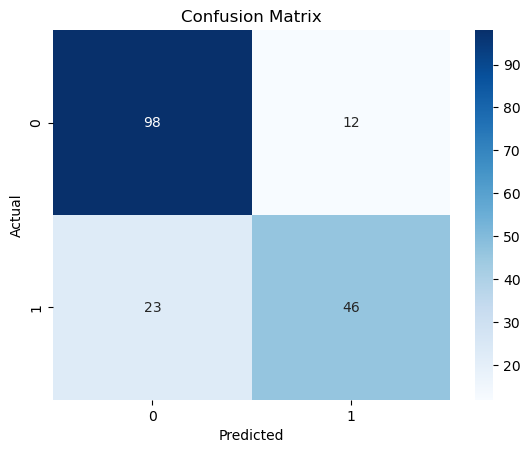


Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


In [17]:
#task 7 Evaluate Model Performance

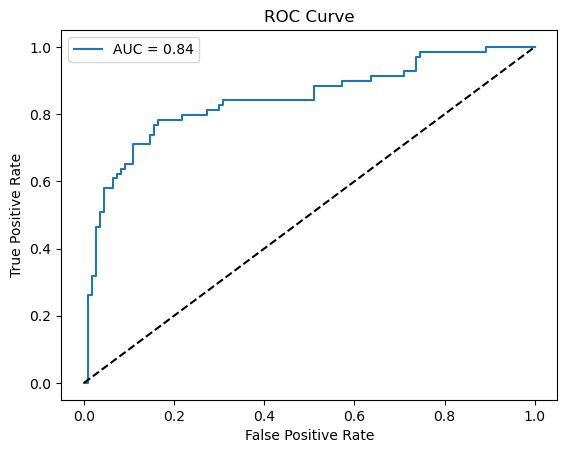

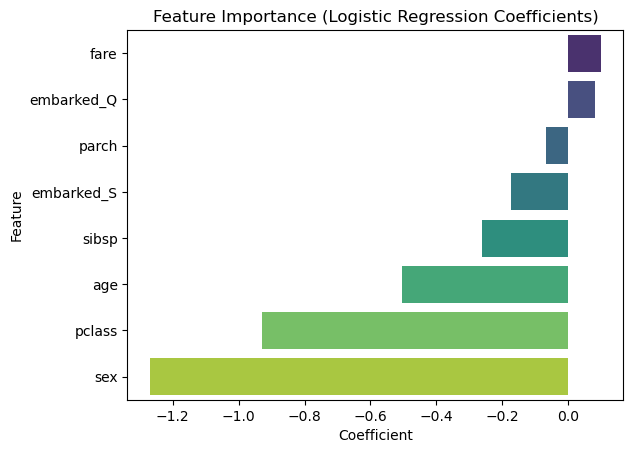

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC curve
y_prob = log_reg.predict_proba(X_test)[:,1]  # Probabilities for class=1
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], 'k--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Feature importance (coefficients)
importance = log_reg.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': importance
}).sort_values(by="Coefficient", ascending=False)

sns.barplot(
    x="Coefficient", 
    y="Feature", 
    data=feature_importance, 
    hue="Feature",      # tell seaborn what’s being colored
    palette="viridis", 
    legend=False        # remove redundant legend
)
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.show()
